In [1]:
import pandas as pd
df_check = pd.read_csv('waca_dataset.csv')
print("target_busy unique values:", df_check['target_busy'].unique())
print("target_busy distribution:", df_check['target_busy'].value_counts().to_dict())

target_busy unique values: [0 1]
target_busy distribution: {0: 140, 1: 60}


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')
# Load data
df = pd.read_csv('waca_dataset.csv')
print("target_busy unique values:", df['target_busy'].unique())
print("target_busy distribution:", df['target_busy'].value_counts().to_dict())
TARGET = df['target_channel'].iloc[0]
feature_cols = [c for c in df.columns 
                if c.endswith(('_mean','_std','_max','_min'))
                and TARGET not in c]
X = df[feature_cols]
y_class = df['target_busy']
y_reg = df['target_throughput']
print(f"\nTarget channel: {TARGET}")
print(f"Features used: {len(feature_cols)}")
print(f"Busy: {y_class.sum()}, Idle: {len(y_class) - y_class.sum()}")
# Train/Test Split
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print(f"Train class dist:\n{yc_train.value_counts()}")

target_busy unique values: [0 1]
target_busy distribution: {0: 140, 1: 60}

Target channel: rssi_temporal_B_b
Features used: 92
Busy: 60, Idle: 140

Train: 160 | Test: 40
Train class dist:
target_busy
0    112
1     48
Name: count, dtype: int64


In [3]:
#Random Forest Classification
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, yc_train)
yc_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(yc_test, yc_pred_rf)
f1_rf  = f1_score(yc_test, yc_pred_rf)
print(f"\nRANDOM FOREST CLASSIFICATION")
print(f"Accuracy: {acc_rf*100:.2f}%  |  F1: {f1_rf:.4f}")
print(classification_report(yc_test, yc_pred_rf, 
                             target_names=['Idle','Busy']))
#Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, yr_train)
yr_pred_rf = rf_reg.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(yr_test, yr_pred_rf))


RANDOM FOREST CLASSIFICATION
Accuracy: 92.50%  |  F1: 0.8571
              precision    recall  f1-score   support

        Idle       0.90      1.00      0.95        28
        Busy       1.00      0.75      0.86        12

    accuracy                           0.93        40
   macro avg       0.95      0.88      0.90        40
weighted avg       0.93      0.93      0.92        40



In [4]:
#XGBoost Classification
xgb_clf = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0)
xgb_clf.fit(X_train, yc_train)
yc_pred_xgb = xgb_clf.predict(X_test)
acc_xgb = accuracy_score(yc_test, yc_pred_xgb)
f1_xgb  = f1_score(yc_test, yc_pred_xgb)
print(f"\nXGBOOST CLASSIFICATION")
print(f"Accuracy: {acc_xgb*100:.2f}%  |  F1: {f1_xgb:.4f}")
print(classification_report(yc_test, yc_pred_xgb,
                             target_names=['Idle','Busy']))
#XGBoost Regression
xgb_reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_reg.fit(X_train, yr_train)
yr_pred_xgb = xgb_reg.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(yr_test, yr_pred_xgb))
print(f"\nREGRESSION RESULTS")
print(f"RF RMSE:  {rmse_rf:.6f}")
print(f"XGB RMSE: {rmse_xgb:.6f}")


XGBOOST CLASSIFICATION
Accuracy: 97.50%  |  F1: 0.9565
              precision    recall  f1-score   support

        Idle       0.97      1.00      0.98        28
        Busy       1.00      0.92      0.96        12

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40


REGRESSION RESULTS
RF RMSE:  0.021247
XGB RMSE: 0.021279


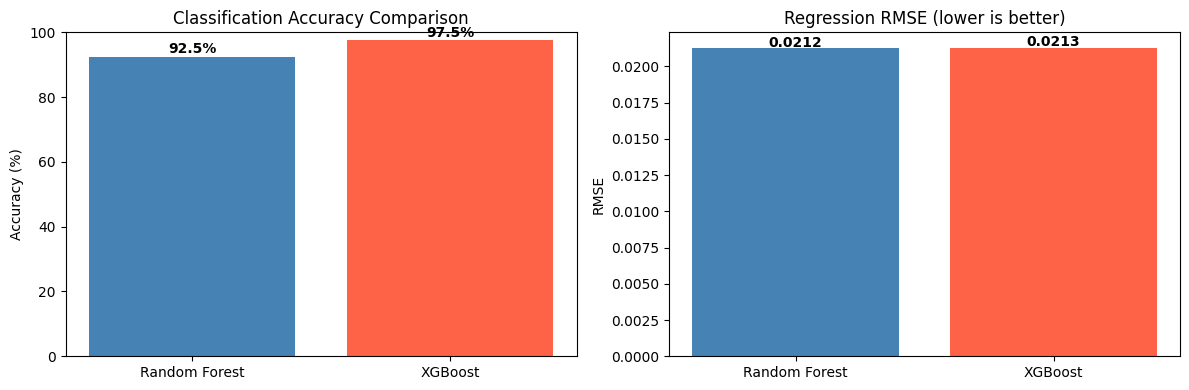

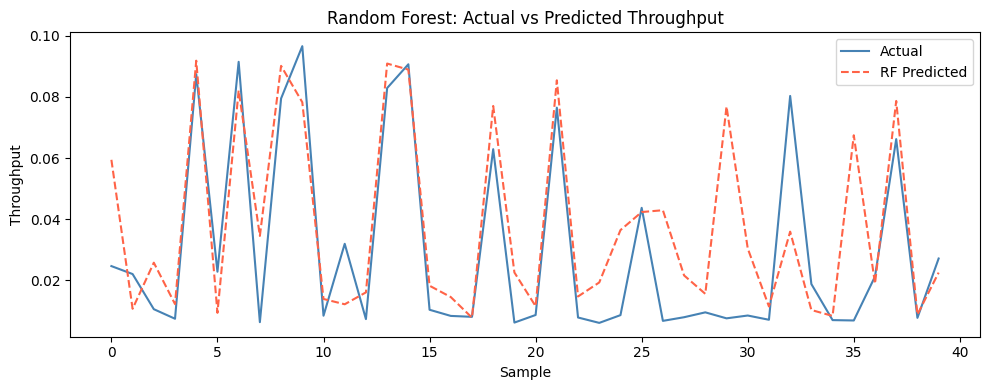

In [5]:
#Plot 1: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(['Random Forest','XGBoost'], 
            [acc_rf*100, acc_xgb*100], color=['steelblue','tomato'])
axes[0].set_title('Classification Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate([acc_rf*100, acc_xgb*100]):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(['Random Forest','XGBoost'],
            [rmse_rf, rmse_xgb], color=['steelblue','tomato'])
axes[1].set_title('Regression RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate([rmse_rf, rmse_xgb]):
    axes[1].text(i, v+0.0001, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
#Plot 2: Throughput Actual vs Predicted
plt.figure(figsize=(10,4))
plt.plot(yr_test.values, label='Actual', color='steelblue')
plt.plot(yr_pred_rf, label='RF Predicted', 
         color='tomato', linestyle='--')
plt.title('Random Forest: Actual vs Predicted Throughput')
plt.xlabel('Sample')
plt.ylabel('Throughput')
plt.legend()
plt.tight_layout()
plt.savefig('rf_throughput.png')
plt.show()

5-FOLD CROSS VALIDATION

Random Forest:
  Accuracy per fold : [0.875 0.925 0.975 0.875 0.875]
  Mean Accuracy     : 90.50% ± 4.00%
  Mean F1           : 0.8149 ± 0.0819

XGBoost:
  Accuracy per fold : [0.925 0.95  0.975 0.95  0.925]
  Mean Accuracy     : 94.50% ± 1.87%
  Mean F1           : 0.9071 ± 0.0317


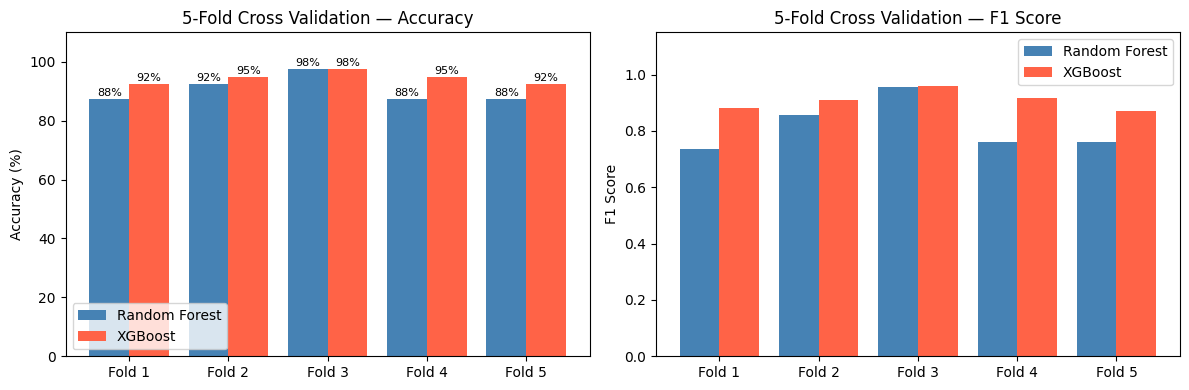

In [6]:
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
print("5-FOLD CROSS VALIDATION")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Random Forest CV
cv_rf_acc = cross_val_score(rf_clf, X, y_class, cv=cv, scoring='accuracy')
cv_rf_f1  = cross_val_score(rf_clf, X, y_class, cv=cv, scoring='f1')
# XGBoost CV
cv_xgb_acc = cross_val_score(xgb_clf, X, y_class, cv=cv, scoring='accuracy')
cv_xgb_f1  = cross_val_score(xgb_clf, X, y_class, cv=cv, scoring='f1')
print(f"\nRandom Forest:")
print(f"  Accuracy per fold : {cv_rf_acc.round(3)}")
print(f"  Mean Accuracy     : {cv_rf_acc.mean()*100:.2f}% ± {cv_rf_acc.std()*100:.2f}%")
print(f"  Mean F1           : {cv_rf_f1.mean():.4f} ± {cv_rf_f1.std():.4f}")
print(f"\nXGBoost:")
print(f"  Accuracy per fold : {cv_xgb_acc.round(3)}")
print(f"  Mean Accuracy     : {cv_xgb_acc.mean()*100:.2f}% ± {cv_xgb_acc.std()*100:.2f}%")
print(f"  Mean F1           : {cv_xgb_f1.mean():.4f} ± {cv_xgb_f1.std():.4f}")
#CV results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(5)
fold_labels = [f'Fold {i+1}' for i in range(5)]
axes[0].bar(x - 0.2, cv_rf_acc*100,  width=0.4, label='Random Forest', color='steelblue')
axes[0].bar(x + 0.2, cv_xgb_acc*100, width=0.4, label='XGBoost',       color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels)
axes[0].set_title('5-Fold Cross Validation — Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()
for i in range(5):
    axes[0].text(i-0.2, cv_rf_acc[i]*100+1,  f'{cv_rf_acc[i]*100:.0f}%', ha='center', fontsize=8)
    axes[0].text(i+0.2, cv_xgb_acc[i]*100+1, f'{cv_xgb_acc[i]*100:.0f}%', ha='center', fontsize=8)
axes[1].bar(x - 0.2, cv_rf_f1,  width=0.4, label='Random Forest', color='steelblue')
axes[1].bar(x + 0.2, cv_xgb_f1, width=0.4, label='XGBoost',       color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_title('5-Fold Cross Validation — F1 Score')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.15)
axes[1].legend()
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

CONFIDENCE INTERVALS (95%)

Random Forest Accuracy: 90.50% ± 5.55%
  95% CI: [84.95%, 96.05%]

XGBoost Accuracy: 94.50% ± 2.60%
  95% CI: [91.90%, 97.10%]


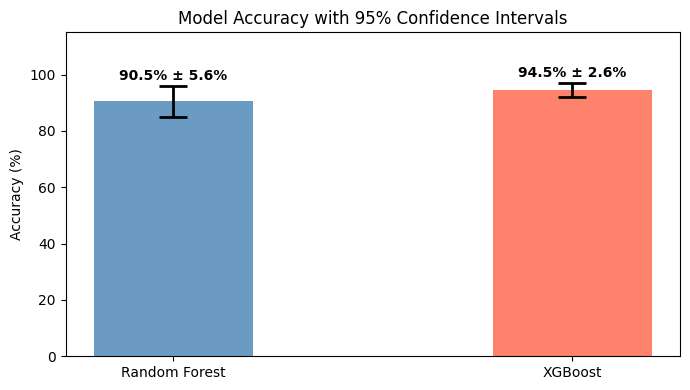

In [7]:
#CONFIDENCE INTERVALS
from scipy import stats
print("CONFIDENCE INTERVALS (95%)")
def confidence_interval_95(scores):
    n    = len(scores)
    mean = scores.mean()
    se   = stats.sem(scores)
    ci   = se * stats.t.ppf((1 + 0.95) / 2., n - 1)
    return mean, ci
rf_mean,  rf_ci  = confidence_interval_95(cv_rf_acc)
xgb_mean, xgb_ci = confidence_interval_95(cv_xgb_acc)
print(f"\nRandom Forest Accuracy: {rf_mean*100:.2f}% ± {rf_ci*100:.2f}%")
print(f"  95% CI: [{(rf_mean - rf_ci)*100:.2f}%, {(rf_mean + rf_ci)*100:.2f}%]")
print(f"\nXGBoost Accuracy: {xgb_mean*100:.2f}% ± {xgb_ci*100:.2f}%")
print(f"  95% CI: [{(xgb_mean - xgb_ci)*100:.2f}%, {(xgb_mean + xgb_ci)*100:.2f}%]")
# Plot confidence intervals
fig, ax = plt.subplots(figsize=(7, 4))
models_list  = ['Random Forest', 'XGBoost']
means        = [rf_mean*100, xgb_mean*100]
cis          = [rf_ci*100,   xgb_ci*100]
colors       = ['steelblue', 'tomato']
bars = ax.bar(models_list, means, color=colors, alpha=0.8, width=0.4)
ax.errorbar(models_list, means, yerr=cis,
            fmt='none', color='black', capsize=10, linewidth=2, capthick=2)
ax.set_title('Model Accuracy with 95% Confidence Intervals')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
for i, (m, c) in enumerate(zip(means, cis)):
    ax.text(i, m + c + 2, f'{m:.1f}% ± {c:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_intervals.png', bbox_inches='tight')
plt.show()

BIAS ANALYSIS
Checking model fairness across different time periods

Early (iter 1-66): Busy=1, Idle=65
  RF  → Acc: 98.5%  F1: 0.000F1=0 because only 1 Busy sample
  XGB → Acc: 98.5%  F1: 0.000

Mid (iter 67-132): Busy=21, Idle=45
  RF  → Acc: 98.5%  F1: 0.976
  XGB → Acc: 100.0%  F1: 1.000

Late (iter 133-200): Busy=38, Idle=30
  RF  → Acc: 98.5%  F1: 0.987
  XGB → Acc: 100.0%  F1: 1.000

RF  accuracy std: 0.0002 → LOW BIAS
XGB accuracy std: 0.0071 → LOW BIAS


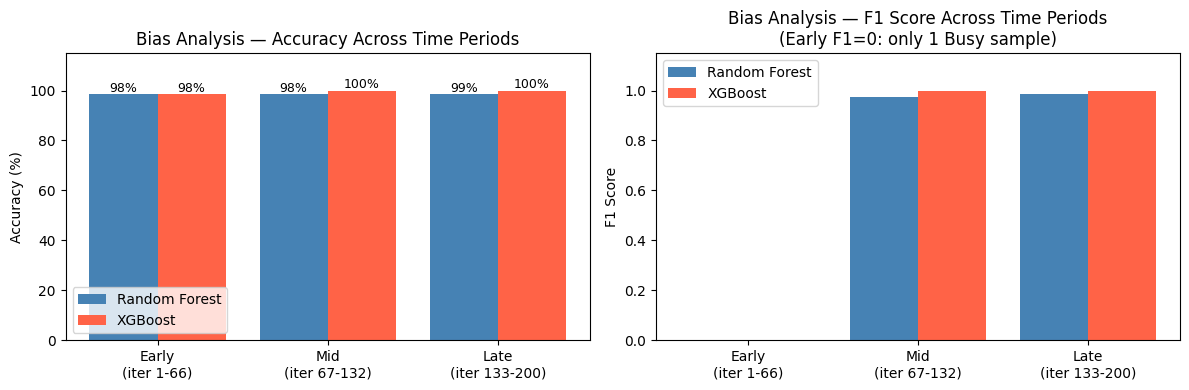

In [8]:
# BIAS ANALYSIS
print("BIAS ANALYSIS")
print("Checking model fairness across different time periods\n")
n = len(df)
third = n // 3
df_early = df.iloc[:third]
df_mid   = df.iloc[third:2*third]
df_late  = df.iloc[2*third:]
results = {}
for period_name, period_df in [('Early\n(iter 1-66)', df_early),
                                ('Mid\n(iter 67-132)', df_mid),
                                ('Late\n(iter 133-200)', df_late)]:
    X_p = period_df[feature_cols]
    y_p = period_df['target_busy']

    acc_rf_p  = accuracy_score(y_p, rf_clf.predict(X_p))
    acc_xgb_p = accuracy_score(y_p, xgb_clf.predict(X_p))
    f1_rf_p   = f1_score(y_p, rf_clf.predict(X_p), zero_division=0)
    f1_xgb_p  = f1_score(y_p, xgb_clf.predict(X_p), zero_division=0)

    results[period_name] = {
        'rf_acc': acc_rf_p, 'xgb_acc': acc_xgb_p,
        'rf_f1': f1_rf_p,   'xgb_f1': f1_xgb_p,
        'busy': y_p.sum(),  'idle': len(y_p) - y_p.sum()}
    print(f"{period_name.replace(chr(10),' ')}: Busy={y_p.sum()}, Idle={len(y_p)-y_p.sum()}")
    print(f"  RF  → Acc: {acc_rf_p*100:.1f}%  F1: {f1_rf_p:.3f}"
          + ("F1=0 because only 1 Busy sample" if f1_rf_p == 0 else ""))
    print(f"  XGB → Acc: {acc_xgb_p*100:.1f}%  F1: {f1_xgb_p:.3f}\n")
rf_accs  = [v['rf_acc']  for v in results.values()]
xgb_accs = [v['xgb_acc'] for v in results.values()]
print(f"RF  accuracy std: {np.std(rf_accs):.4f} → {'LOW BIAS' if np.std(rf_accs)<0.05 else 'Some variance'}")
print(f"XGB accuracy std: {np.std(xgb_accs):.4f} → {'LOW BIAS' if np.std(xgb_accs)<0.05 else 'Some variance'}")
# Plot
periods  = list(results.keys())
rf_accs_p  = [results[p]['rf_acc']*100  for p in periods]
xgb_accs_p = [results[p]['xgb_acc']*100 for p in periods]
x = np.arange(len(periods))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - 0.2, rf_accs_p,  width=0.4, label='Random Forest', color='steelblue')
axes[0].bar(x + 0.2, xgb_accs_p, width=0.4, label='XGBoost',       color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(periods)
axes[0].set_title('Bias Analysis — Accuracy Across Time Periods')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].legend()
for i in range(len(periods)):
    axes[0].text(i-0.2, rf_accs_p[i]+1,  f'{rf_accs_p[i]:.0f}%',  ha='center', fontsize=9)
    axes[0].text(i+0.2, xgb_accs_p[i]+1, f'{xgb_accs_p[i]:.0f}%', ha='center', fontsize=9)
rf_f1s  = [results[p]['rf_f1']  for p in periods]
xgb_f1s = [results[p]['xgb_f1'] for p in periods]
axes[1].bar(x - 0.2, rf_f1s,  width=0.4, label='Random Forest', color='steelblue')
axes[1].bar(x + 0.2, xgb_f1s, width=0.4, label='XGBoost',       color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(periods)
axes[1].set_title('Bias Analysis — F1 Score Across Time Periods\n(Early F1=0: only 1 Busy sample)')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.15)
axes[1].legend()
plt.tight_layout()
plt.savefig('bias_analysis.png', bbox_inches='tight')
plt.show()